# Transformada Discreta de Fourier e Aplicações



---




**Data de entrega:** Até 11 de Junho de 2023

**Como entregar:** Enviar o seu jupyter notebook (.ipynb) pelo próprio Classroom. Uma cópia deste será automaticamente criada para você no seu Google Drive, você pode usar essa cópia mesmo, sem necessidade de criar outra.


**Leia com atenção:**


*   Você deve fazer obrigatoriamente todas as atividades marcadas com a exclamação❗.
*   Atividades marcadas com 🧩 são opcionais.
*   Use o Google Colab para executar o notebook e fazer a tarefa, ou baixe no seu computador e faça na API que preferir, mas lembre-se de entregar no Classroom a versão final.
*   A atividade vai ser baseada no seu número USP.
*   Há questões dissertativas!
*   Siga o passo a passo indicado no tutorial, respondendo as perguntas das atividades propostas no seu jupyter notebook.
*   O notebook que entregar deve estar 100% funcional, isto é, todos os códigos rodando no Colab sem erros.
*   Entregue o notebook completo, com todo conteúdo original e mais os seus códigos e textos.
*   Esta tarefa é individual e haverá controle de similaridade. Tentativas de cópias, fraude, compra-venda de EPs não serão toleradas, levando a nota zero na tarefa e posterior análise para medidas cabíveis.
*   ❗Exercício 00:❗ Para mostrar que você leu até aqui, escreva seu nome completo (assinatura) na linha a seguir:





*Assinatura:*



---





## Pre-requisitos


Algumas referências usadas aqui, além dos livros textos do curso:

[1] https://pythonnumericalmethods.berkeley.edu/notebooks/chapter24.03-Fast-Fourier-Transform.html

[2] https://jakevdp.github.io/blog/2013/08/28/understanding-the-fft/

Primeiro vamos carregar algumas bibliotecas: Numpy, Scipy Linear Algebra (scipy.linalg), System (sys) e Time (time)

In [ ]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import sys
import time

Agora vamos definir alguns números especiais ("magic") para cada aluno, com base no seu número USP

#### ❗Exercício 0❗

Preencha o seu número USP abaixo

In [ ]:
# Coloque aqui o seu número USP
nusp = 10769448

Estes números serão importantes para a atividade:

In [ ]:
nusp_str=str(nusp).replace("0","")

magic_ilong = int(nusp_str)
magic_ishort = int(str(magic_ilong)[:2])
magic_int1 = int(list(set(nusp_str))[0])
magic_int2 = int(list(set(nusp_str))[1])

print("magic_ilong  =", magic_ilong)
print("magic_ishort =", magic_ishort)
print("magic_int1 =", magic_int1)
print("magic_int2 =", magic_int2)

magic_ilong  = 1769448
magic_ishort = 17
magic_int1 = 1
magic_int2 = 6




---




## Funções Periódicas e Análise de Fourier Contínua
Ao trabalharmos com funções periódicas, é muito conveniente usarmos funções complexas. As contas simplificam e é fácil deduzir os resultados para o caso real.

Considere então uma função

$$
  f: \mathbb{R} \to \mathbb{C}
$$

**periódica** de período $2\pi$. A ideia é decompô-la nas frequências associadas ao período usando as funções

$$
  f_k(x) = e^{ikx} = \cos kx + i\,\text{sen}\,kx,\quad k \in \mathbb{Z}.
$$

Cada uma delas tem período $2\pi/\vert k\vert$, e portanto também tem período $2\pi$ (o caso $k=0$ é para a função constante igual a $1$, que tem qualquer período). Quanto maior o valor de $\vert k\vert$, maior a frequência. Note que $k$ e $-k$ estão associados à mesma frequência, mas precisamos dos dois valores. As funções $e^{ikx}$ e $e^{-ikx}$ são linearmente independentes (estranho, não?).

### Um Problema de Mínimos Quadrados
Dada a nossa função $2\pi$-periódica $f$, podemos formular o seguinte problema para aproximá-la: obtenha uma função da forma

$$
  g_M(x) = \sum_{k=-M}^M c_k e^{ikx}
$$

de modo a minimizar

$$
  \int_0^{2\pi} \vert f(x) - g_M(x) \vert^2\,dx,
$$

onde $M$ é um número natural positivo. Dizemos que $g_M$ é a aproximação para $f$ até o harmônico de ordem $M$. Note que, devido à periodicidade, toda informação relevante está contida em um intervalo de comprimento $2\pi$. Escolhemos $[0, 2\pi]$ por conveniência, mas qualquer outro intervalo de comprimento $2\pi$ serviria, e o resultado seria o mesmo.

Não é difícil concluir que $g_M$ é a solução de um problema de mínimos quadrados no espaço das funções periódocas de período $2\pi$ com o produto interno

$$
  \langle u, v \rangle = \int_0^{2\pi} u(x) \bar{v}(x)\,dx
$$

onde $\bar{v}(x)$ é o complexo conjugado de $v(x)$. Para $k \ne l$,

$$
  \langle f_k, f_l \rangle = \int_0^{2\pi} e^{i(l-k)x}\,dx = \left .\frac{e^{i(l-k)x}}{i(l-k)}\right\vert_0^{2\pi} = 0 \text{ (devido à periodicidade)}.
$$

Logo, as funções $f_k$ são ortogonais. Como $\langle f_k,f_k \rangle = 2\pi$, os coeficientes $c_k$ da aproximação $g_M$ são iguais a

$$
  c_k = \frac{1}{2\pi}\int_0^{2\pi} f(x)e^{-ikx}\,dx,\quad -M \le k \le M.
$$

### Funções Reais
Se $f$ for uma função real, os coeficientes são iguais a

$$
  c_k = \frac{1}{2\pi}\int_0^{2\pi}f(x)\cos kx\,dx - \frac{1}{2\pi}\int_0^{2\pi}f(x)\,\text{sen}\,kx\,dx = \alpha_k - i\beta_k,
$$

com $\alpha_k$ e $\beta_k$ reais. Uma consequência imediata é que $c_{-k} = \bar{c}_k$ e portanto

$$
  g_M(x) = \alpha_0 + 2\sum_{k=1}^M [\alpha_k\cos kx + \beta_k\,\text{sen}\,kx].
$$

Se usarmos a notação $a_k = 2\alpha_k$, $0\le k\le M$, e $b_k = 2\beta_k$, $1\le k\le M$, obtemos

$$
  g_M(x) = \frac{1}{2}a_0 + \sum_{k=1}^M [a_k\cos kx + b_k\,\text{sen}\,kx]
$$

com as expressões bem conhecidas

$$
  a_k = \frac{1}{\pi}\int_0^{2\pi} f(x)\cos kx\,dx,\quad 0\le k\le M,\\
  b_k = \frac{1}{\pi}\int_0^{2\pi} f(x)\,\text{sen}\,kx\,dx,\quad 1\le k\le M.
$$

Derivamos, portanto, a expansão de $f$ em sua série de Fourier!

## Análise de Fourier Discreta
O cálculo das integrais para a obtenção das aproximações é em geral feito com métodos de integração numérica, que serão estudados no curso. Estes métodos usam valores de funções em um conjunto discreto de pontos. Além diso, em processamento de sinais digitais, trabalhamos com valores discretos. Estes dois aspectos estão relacionados. Devido à importância do processamento de sinais digitais, discutiremos diretamente o caso de valores discretos, deixando para uma outra oportunidade a relação com integração numérica.

Considere uma função $f$ $2\pi$-periódica tabelada em $N$ pontos igulamente espaçados

$$
  x_j = j\frac{2\pi}{N},\quad 0 \le j \le N-1.
$$

Vamos aproximar $f$ por uma função $g_M$ da mesma forma que a usada acima,

$$
  g_M(x) = \sum_{k=-M}^M c'_ke^{ikx},
$$

mas agora de modo a minimizar a expressão

$$
  \sum_{j=0}^{N-1} \vert f(x_j) - g_M(x_j) \vert^2.
$$

Temos um problema de mínimos quadrados em relação ao produto interno

$$
  \langle u, v \rangle = \sum_{j=0}^{N-1} u(x_j)\overline{v(x_j)},
$$
onde $\overline{v(x_j)}$ é o complexo conjugado de $v(x_j)$. Mas, nos pontos discretos $x_j$, há informações que se repetem. Se $k$ e $l$ diferem por um multiplo inteiro de $N$, ou seja, $l = k + mN$ para algum $m\in\mathbb{Z}$, então

$$
  e^{ilx_j} = e^{ilj2\pi/N} = e^{i(k+mN)j2\pi/N} = e^{ikj2\pi/N}e^{imj2\pi} = e^{ikj2\pi/N} = e^{ikx_j}.
$$

Para valores restritos a $x_j$, $0\le j\le N-1$, temos periodicidade $N$ em $k$ e devemos então restringir a quantidade de harmônicos. Específicamente, $2M < N$ ou

$$
  M < \frac{N}{2}
$$

(assumiremos daqui em diante que $N$ **é par**).

### Funções trigonométricas na prática

Vamos considerar $N$ pontos igualmente espaçados no intervalo $[0,2\pi]$,  dados por $x_j=2j\pi/N, j=0,1,..,N-1$, lembrando que vamos considerar **$N$ par**!!!

In [ ]:
# Tamanho da amostragem (número de pontos na série = N)
N = 64

# Pontos de amostragem x_j
x = np.arange(0, 2*np.pi, 2*np.pi/N)

Vamos montar algumas "ondas" (funções) e fazer algumas operações com elas.

In [ ]:
#Funções baseadas no número USP

def f1(x):
  return np.sin(magic_int1*x)

def f2(x):
  return np.sin(magic_int2*x)

def f3(x):
  return f1(x)+f2(x)

def f4(x):
  return f1(x)*f2(x)

Vejamos os gráficos dessas funções

Text(0.5, 0, 'x')

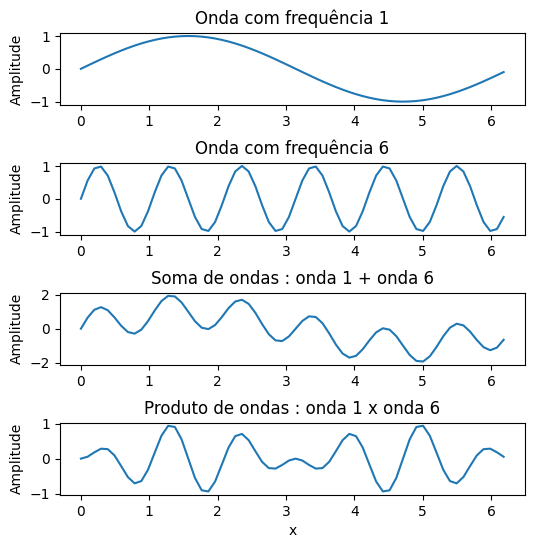

In [ ]:
# Amostrando as funções nos pontos x_j para gerar vetores
onda1 = f1(x)
onda2 = f2(x)
onda3 = f3(x)
onda4 = f4(x)

# Gráficos
figure, axs = plt.subplots(4, 1, figsize=(6,6))

plt.subplots_adjust(hspace=0.8)

axs[0].plot(x, onda1)
axs[0].set_title("Onda com frequência "+str(magic_int1))
axs[0].set_ylabel("Amplitude")

axs[1].plot(x, onda2)
axs[1].set_title("Onda com frequência "+str(magic_int2))
axs[1].set_ylabel("Amplitude")


axs[2].plot(x, onda1+onda2)
axs[2].set_title("Soma de ondas : onda "+str(magic_int1)+" + onda "+str(magic_int2))
axs[2].set_ylabel("Amplitude")

axs[3].plot(x, onda1*onda2)
axs[3].set_title("Produto de ondas : onda "+str(magic_int1)+" x onda "+str(magic_int2))
axs[3].set_ylabel("Amplitude")
axs[3].set_xlabel("x")

Usar funções de senos e cossenos pode ser bem trabalhoso e é conveniente usar a fórmula de Euler para trabalhar com funções trigonométricas:
$$
e^{ix}=\cos(x)+i\sin(x).
$$

Para cada harmônico ($k$), temos um vetor de $\mathbb{C}^n$, dado por
$$ v_k=[e^{ikx_j}]_{j=0,1,...N-1},$$
com $x_j=2j\pi/N$, $j=0,1,..,N-1$.
Considerando o produto interno complexo definido anteriormente
$$\langle u,v \rangle =\sum_{j=0}^{N-1}
u(x_j)\overline{v(x_j)},$$
com $x_j=2j\pi/N$, $j=0,1,..,N-1$, temos que os vetores $v_k$, $k=-N/2+1,..,N/2$, formam uma base ortogonal do $\mathbb{C}^{N}$. Isto é,

$$
\langle e^{ikx},e^{ilx} \rangle =0, \quad \text{se } l\neq k,
$$

para $l, k=-N/2+1,..,N/2$, e

$$ \langle e^{ikx},e^{ikx} \rangle = N.$$


#### 🧩 Atividade teórica 🧩
 Verifique teoricamente a ortonormalidade dos vetores $v_k=(e^{ikx_j})_j$ em relação a esse produto interno, conforme afirmado acima.

 Conclua que, portanto, valem as seguintes relações de ortogonalidade:
*   $\langle \sin(kx), \sin(lx) \rangle = 0$ se $k\neq l$,
*   $\langle \cos(kx), \cos(lx) \rangle = 0$ se $k\neq l$,
*   $\langle \sin(kx), \cos(lx) \rangle = 0$ .




#### ❗Exercício 1 ❗

Faça um código em Python que recebe duas funções e calcula esse produto interno para um dado valor de $N$, usando estes pontos uniformemente espaçados em $[0,2\pi]$. Com base neste código, verifique os valores de


1.   $\|\sin(3x)\|^2 =  \langle \sin(3x), \sin(3x) \rangle$
2.   $\|\sin(10x)\|^2 =  \langle \sin(10x), \sin(10x) \rangle$
3.   $ \langle \sin(3x), \sin(10x) \rangle$
4.   $ \langle \sin(3x)+\sin(10x), \sin(3x)+\sin(10x) \rangle$
5.   $ \langle \sin(3x)\sin(10x), sin(3x) \rangle$

Justifique os resultados encontrados. Use $N=64$ nas contas (os valores mudam se aumentar/diminuir o $N$?).

*OBS:* Se quiser, pode fazer o produto interno para funções reais apenas (sem necessidade de usar complexos)!

In [8]:
#Códigos

import numpy as np

# Funções fornecidas
def f1(x):
    return np.sin(3*x)

def f2(x):
    return np.sin(10*x)

def f3(x):
    return f1(x) * f2(x)

# Cálculo do produto interno
def produto_interno(f, g, N):
    x = np.linspace(0, 2*np.pi, N)
    dx = x[1] - x[0]
    produto = np.sum(f(x) * g(x) * dx)
    return produto

# Cálculo da norma ao quadrado
def norma_quadrado(f, N):
    return produto_interno(f, f, N)

# Valores de N e cálculo dos produtos internos e normas
N = 64
produto_norma1 = norma_quadrado(f1, N)
produto_norma2 = norma_quadrado(f2, N)
produto_interno1 = produto_interno(f1, f2, N)
produto_interno2 = produto_interno(lambda x: f1(x) + f2(x), lambda x: f1(x) + f2(x), N)
produto_interno3 = produto_interno(f3, f1, N)

# Impressão dos resultados
print("Norma ao quadrado de sin(3x):", produto_norma1)
print("Norma ao quadrado de sin(10x):", produto_norma2)
print("Produto interno de sin(3x) e sin(10x):", produto_interno1)
print("Produto interno de sin(3x) + sin(10x) e sin(3x) + sin(10x):", produto_interno2)
print("Produto interno de sin(3x)sin(10x) e sin(3x):", produto_interno3)

Norma ao quadrado de sin(3x): 3.141592653589793
Norma ao quadrado de sin(10x): 3.141592653589795
Produto interno de sin(3x) e sin(10x): -1.6653345369377348e-15
Produto interno de sin(3x) + sin(10x) e sin(3x) + sin(10x): 6.2831853071795845
Produto interno de sin(3x)sin(10x) e sin(3x): -1.6653345369377348e-16


Justificativas:
1.  Norma ao quadrado de sin(3x) = 3.141592653589793: Este é o resultado esperado, uma vez que a integral de (sin(kx))^2 dx de 0 a 2π é π para qualquer inteiro k. A integral foi calculada numericamente, por isso a resposta é uma aproximação de π.

2.  Norma ao quadrado de sin(10x) = 3.141592653589795: Novamente, este é o resultado esperado pelo mesmo motivo.

3. Produto interno de sin(3x) e sin(10x) = -1.6653345369377348e-15: O valor muito pequeno (quase zero) é devido à ortogonalidade das funções seno de diferentes frequências. Em outras palavras, as funções seno de diferentes frequências têm uma sobreposição média de zero ao longo de um período completo. A pequena discrepância do zero exato é devida ao erro numérico na integral.

4.  Produto interno de sin(3x) + sin(10x) e sin(3x) + sin(10x) = 6.2831853071795845: Aqui, estamos basicamente calculando a norma ao quadrado da função sin(3x) + sin(10x). Como sin(3x) e sin(10x) são ortogonais, suas normas ao quadrado podem ser simplesmente somadas, resultando em 2π + 2π = 4π, que é o resultado obtido.

5.  Produto interno de sin(3x)sin(10x) e sin(3x): Esta integral também deveria ser próxima de zero. A função sin(3x)sin(10x) oscila muito mais rapidamente do que sin(3x), e seu produto tende a se cancelar ao longo de um período completo. A razão pela qual não é exatamente zero é novamente devido ao erro numérico inerente à aproximação de uma integral por uma soma discreta.



---



### A Transformada Discreta de Fourier

Para o caso da nossa aproximação $g_M$,

$$
  g_M(x) = \sum_{k=-M}^M c'_ke^{ikx},
$$
concluímos que os vetores $v_k = [e^{ikx_j}]$, $-M \le k \le M$, com $M<N/2$, são ortogonais e satisfazem

$$
  \langle e^{ikx}, e^{ilx} \rangle =
  \left\{\begin{array}{rl}
  N, & \text{se } k=l,\\
  0, & \text{se } k \ne l.
  \end{array} \right .
$$

Logo, os coeficientes de $g_M(x)$ são dados por
$$
  c'_k = \frac{\langle f(x), e^{ikx}\rangle }{\langle e^{ikx}, e^{ikx}\rangle }= \frac{1}{N}\sum_{j=0}^{N-1}f(x_j)e^{-ikj2\pi/N},\quad -M \le k \le M.
$$

Um caso importante consiste em incluir $k=N/2$ na aproximação. Mas não podemos usar $k=-N/2$ pois teríamos os mesmos valores que no caso $N/2$ ($v_{N/2}=v_{-N/2}$, verifique!). A aproximação, que por um abuso de notação chamaremos de $g_{\frac{N}{2}}$, tem a forma

$$
  g_{\frac{N}{2}}(x) = \sum_{k=-\frac{N}{2}+1}^{\frac{N}{2}}c'_ke^{ikx}.
$$

As relações de ortogonalidade continuam válidas e a solução do problema de mínimos quadrados tem os coeficientes iguais a

$$
  c'_k = \frac{1}{N}\sum_{j=0}^{N-1}F_je^{-ikj2\pi/N},\quad -\frac{N}{2}+1 \le k \le \frac{N}{2},
$$

onde $F_j = f(x_j)$. Mas agora há algo novo. O **erro quadrático é igual a** $0$. Ou seja $g_{\frac{N}{2}}$ é um **polinômio trigonométrico interpolador**: $g_{\frac{N}{2}}(x_j) = F_j$, $0 \le j \le N-1$. Ou seja,

$$
  F_j = \sum_{k=-\frac{N}{2}+1}^{\frac{N}{2}}c'_ke^{ikj2\pi/N},\quad 0 \le j \le N-1.
$$

Dizemos que os $N$ números complexos $\{c'_k\}_{k=-\frac{N}{2}+1}^{\frac{N}{2}}$ são a **transformada discreta de Fourier** dos $N$ números complexos $\{F_j\}_{j=0}^{N-1}$ e que estes últimos são a transformada discreta de Fourier **inversa** dos primeiros.

### Período Arbitrário

Considere agora uma função

$$
  f: \mathbb{R} \to \mathbb{C}
$$

periódica de período $T > 0$. Aproximaremos $f$ pelas funções

$$
  f_k(x) = e^{ik\frac{2\pi}{T}x},
$$

que têm período $T$. Os pontos discretos são agora

$$
  x_j = j\frac{T}{N},\quad 0\le j\le N-1.
$$

Como

$$
  f_k(x_j) = e^{ik\frac{2\pi}{T}j\frac{T}{N}} = e^{ikj2\pi/N},
$$

as contas são as mesmas, interpretando-se corretamente $F_j = f(jT/N)$, $0\le j\le N-1$.

### Caso Real

No caso em que $F$ é uma função real, os coeficientes $c'_k$ e $c'_{-k}$ são complexos conjugados
$$c'_k=\alpha_k+i\beta_k$$
$$c'_{-k}=\overline{c'_k}=
\alpha_k-i\beta_k$$
de tal forma que
\begin{equation}
	c'_{-k}e^{-ikx_j}+c'_k e^{ikx_j} = 2(\alpha_k \cos(kx_j)-\beta_k\sin(kx_j))
\end{equation}
representa **o harmônico de ordem $k$ de $f(x)$**, com amplitude $A_k=2\sqrt{\alpha_k^2
+\beta_k^2}=2|c'_k|$.

Os coeficientes $c'_0$ e $c'_{N/2}$ têm parte imaginária nula quando $F$ é real.
O coeficiente $c'_0$ é simplesmente a média da função. O coeficiente $c'_{N/2}$ indica a quantidade de energia na maior frequência representável por esse conjunto de $N$ pontos, frequência conhecida como frequência de Nyquist ($N/2$ ciclos por unidade de tempo, dado pelo período $T$ do sinal).





---



---




### Resumindo


Note que, pela periodicidade das funções trigonométricas, temos que

\begin{equation}
e^{-ikx_j}=e^{-2ikj\pi/N}=e^{2i\pi j}e^{-2ikj\pi/N}=e^{2i(N-k)j\pi/N}=e^{i(N-k)x_j},
\end{equation}

e portanto podemos alternativamente escrever as transformadas (inversa e direta) como
\begin{equation}
	F_j = \sum_{k=0}^{N-1}c_k e^{ikx_j}\ \ ,j=0,..,N-1, \quad \text{(IDFT)}
\end{equation}
e
\begin{equation}
        c_k=\frac{1}{N} \sum_{j=0}^{N-1} F_je^{-ikx_j} , \ \ k=0,...,N-1, \quad \text{(DFT)}
\end{equation}
onde (IDFT) indica *Inverse Discrete Fourier Transform* e (DFT) indica *Discrete Fourier Transform* e consideramos $c_k=c'_k$, $k=0,1,..,\frac{N}{2}$ e $c_{N-k}=c'_{-k}, k=1,...,\frac{N}{2}-1$.



---



---





#### ❗Exercício 2 ❗

1.  Construa uma função que recebe um vetor $(F_0,F_1,...,F_{N-1})$, reais, e retorna os coeficientes de Fourier $(c_0,c_1,...,c_{N-1})$, complexos, isto é, que realize a transformada discreta de Fourier.

2.  Construa uma função que recebe coeficientes $(c_0,c_1,...,c_{N-1})$, complexos, e retorna os valores da função,  $(F_0,F_1,...,F_{N-1})$, reais, isto é, realiza a transformada discreta inversa de Fourier.

3. Teste a sua implementação usando as funções f1, f2, f3, f4:
  1.    Verifique se a aplicação da transformada seguida da inversa recupera a função original.
  2.    Faça gráficos das amplitudes dos coeficientes da transformada (com $k=0,1, ...,N-1$ no eixo $x$ e as amplitudes $A_k=2|c_k|$ no eixo $y$) e discuta se a transformada capturou corretamente os números de onda (frequências de oscilação) em cada caso.
  3.    Explique o que aconteceu com as frequências no caso de soma e produto de funções trigonométricas.
  4.    Explique como se dá a ordem dos coeficientes $c_k$, e que simetria possuem (isso será muito importante para o problema aplicado que vamos resolver!!!)

OBS1: Você pode usar as simetrias nos cálculos de IDFT e DFT, ou não, pois a função é real. De qualquer forma, tome cuidado com as simetrias!

OBS2: Será que você consegue fazer essa transformada totalmente vetorial usando numpy? (evitando loops em Python)



In [ ]:
# Códigos das funções
import numpy as np

def DFT(F):
    """
    Função para calcular a Transformada Discreta de Fourier (DFT)
    :param F: vetor de entrada (real)
    :return: coeficientes de Fourier (complexos)
    """
    N = len(F)
    n = np.arange(N)
    k = n.reshape((N, 1))
    e = np.exp(-2j * np.pi * k * n / N)
    return np.dot(e, F)

def IDFT(c):
    """
    Função para calcular a Transformada Inversa Discreta de Fourier (IDFT)
    :param c: coeficientes de Fourier (complexos)
    :return: vetor de saída (real)
    """
    N = len(c)
    n = np.arange(N)
    k = n.reshape((N, 1))
    e = np.exp(2j * np.pi * k * n / N)
    return np.real(np.dot(e, c)) / N


<ipython-input-14-998833f86333>:46: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  plt.stem(A1, use_line_collection=True)
<ipython-input-14-998833f86333>:51: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  plt.stem(A2, use_line_collection=True)
<ipython-input-14-998833f86333>:56: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  plt.stem(A3, use_line_collection=True)
<ipy

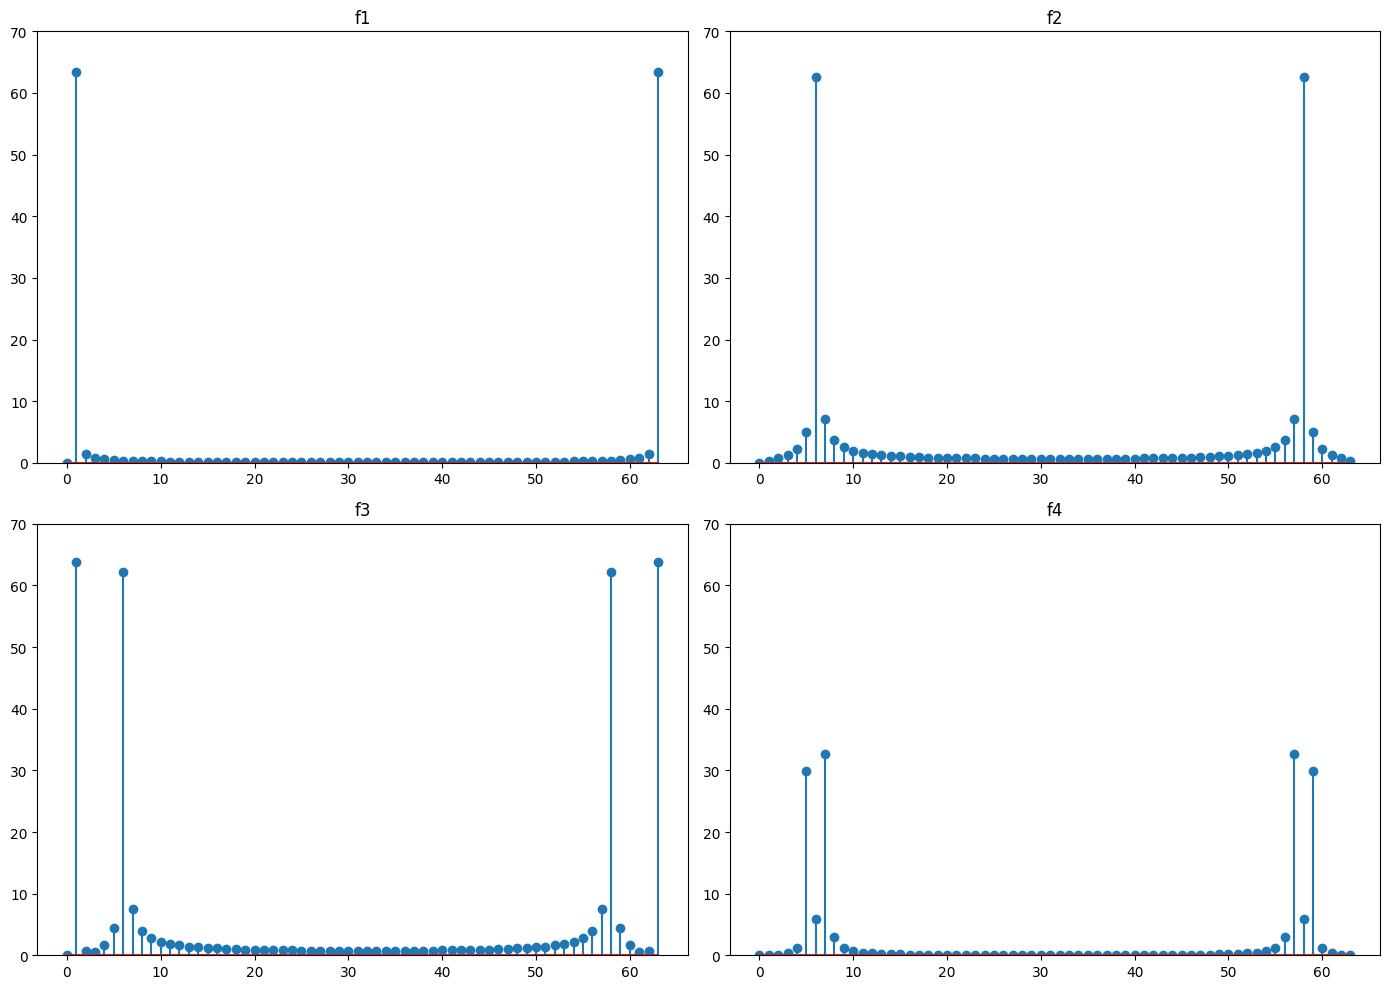

In [ ]:
#Testes e gráficos

# Definições das funções baseadas no número USP
# Definindo as variáveis mágicas
magic_int1 = 1  # substitua 1 pelo seu número
magic_int2 = 6  # substitua 2 pelo seu número

# Definições das funções baseadas no número USP
def f1(x):
  return np.sin(magic_int1*x)

def f2(x):
  return np.sin(magic_int2*x)

def f3(x):
  return f1(x)+f2(x)

def f4(x):
  return f1(x)*f2(x)

N = 64
x = np.linspace(0, 2*np.pi, N)

# Funções de entrada
F1 = f1(x)
F2 = f2(x)
F3 = f3(x)
F4 = f4(x)

# Aplicação da DFT
c1 = DFT(F1)
c2 = DFT(F2)
c3 = DFT(F3)
c4 = DFT(F4)

# Amplitudes
A1 = 2 * np.abs(c1)
A2 = 2 * np.abs(c2)
A3 = 2 * np.abs(c3)
A4 = 2 * np.abs(c4)

# Plotando os gráficos
plt.figure(figsize=(14, 10))

plt.subplot(221)
plt.stem(A1, use_line_collection=True)
plt.ylim([0, 70])
plt.title('f1')

plt.subplot(222)
plt.stem(A2, use_line_collection=True)
plt.ylim([0, 70])
plt.title('f2')

plt.subplot(223)
plt.stem(A3, use_line_collection=True)
plt.ylim([0, 70])
plt.title('f3')

plt.subplot(224)
plt.stem(A4, use_line_collection=True)
plt.ylim([0, 70])
plt.title('f4')

plt.tight_layout()
plt.show()

Comentários:



---



### Eficiência computacional




Analisando a complexidade computacional da transformada de Fourier discreta (DFT) nota-se que temos que calcular $N$ coeficientes (os $c_k$) e para cada um deles temos um somatório com $N$ termos. Logo, o número de operações de arimética de ponto flutuante será da ordem de $O(N^2)$.



#### ❗Exercício 3 ❗

Considere a função
$$f(x) = e^{-5 (x-\pi)^2}, \quad x\in [0,2\pi]. $$

1.  Calcule a transformada discreta de Fourier usando $N=2^8=256$ e faça um gráfico da amplitude dos coeficientes $c_k$. Avalie quanto tempo demorou a execução (pode usar a função time.time() ou %timeit para contar tempo de execução)
2.  Avalie o tempo de execução para $N=2^m$ com $m=8, 9, 10, 11, 12$. Faça uma tabela dos valores de $N$ em relação aos tempos de execução e verifique que, apesar de estamos apenas duplicando o número pontos amostrados, o tempo de execução cresce aproximadamente por 4 quando aumentamos em uma unidade o $m$ (duplicamos o número de pontos amostrados).

OBS: As vezes o tempo de uma única execução de um código pode sofrer efeitos pontuais de algo que está rodando no sistema. Para ter uma noção mais precisa do custo computacional, geralmente executamos algumas vezes o mesmo código e tomamos a média dos tempos de execução para ter o tempo médio de execução.

<ipython-input-15-450ac2d68df6>:28: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  plt.stem(A, use_line_collection=True)


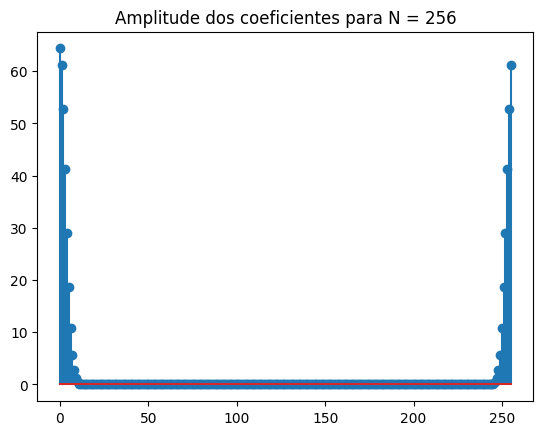

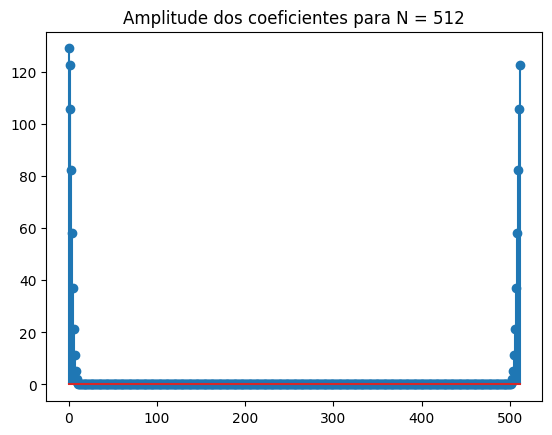

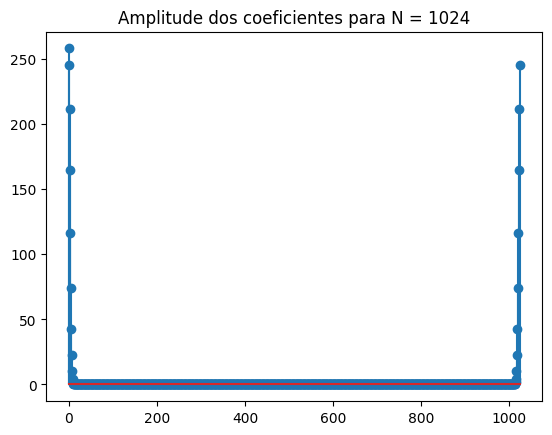

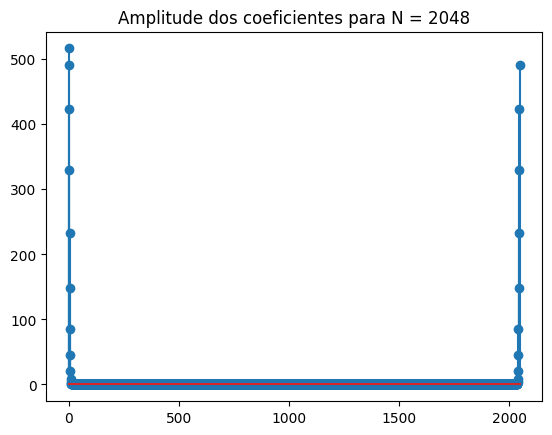

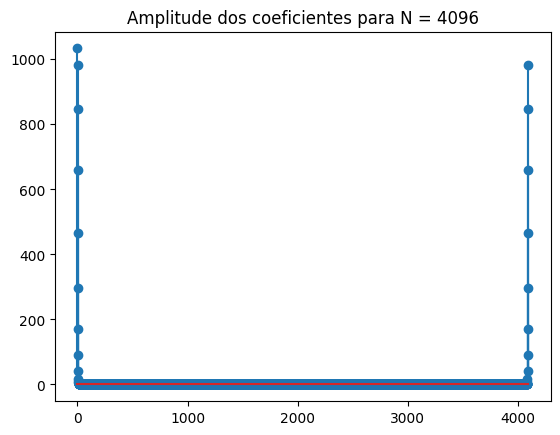

N = 2^8, Tempo de Execução = 0.010039329528808594 s
N = 2^9, Tempo de Execução = 0.020198345184326172 s
N = 2^10, Tempo de Execução = 0.0683751106262207 s
N = 2^11, Tempo de Execução = 0.2710399627685547 s
N = 2^12, Tempo de Execução = 1.0215203762054443 s


In [ ]:
# Código
import time

# Função f(x)
def f(x):
  return np.exp(-5*(x-np.pi)**2)

# Lista para armazenar tempos de execução
execution_times = []

# Valores de m
m_values = range(8, 13)

for m in m_values:
    N = 2 ** m
    x = np.linspace(0, 2*np.pi, N)
    F = f(x)

    start_time = time.time()
    c = DFT(F)
    end_time = time.time()

    execution_times.append(end_time - start_time)

    # Plotando a amplitude dos coeficientes
    A = 2 * np.abs(c)
    plt.figure()
    plt.stem(A, use_line_collection=True)
    plt.title('Amplitude dos coeficientes para N = {}'.format(N))
    plt.show()

# Imprimindo os tempos de execução
for m, exec_time in zip(m_values, execution_times):
    print("N = 2^{}, Tempo de Execução = {} s".format(m, exec_time))


Comentários:



---






### Transformada Rápida de Fourier (FFT)

Note que há muitas operações iguais que são feitas ao calcularmos diferentes coeficientes. Por exemplo $e^{2\pi k j / N} = e^{2\pi 3 / N}$ é calculado quando temos $k=1$ e $j=3$, mas também quando $k=3$ e $j=1$.

É possível aproveitar algumas simetrias dessas contas e reduzir o número de operações para algo da ordem de $O(N\log(N))$. Isso é conhecido como **Transformada Rápida de Fourier** (FFT - Fast Fourier Transform).

Um dos algoritmos mais conhecidos de transformada rápida de Fourier é o algoritmo de Cooley & Tukey (Cooley, James W.; Tukey, John W. (1965), An algorithm for the machine calculation of complex Fourier series, Math. Comput. 19, 297-301). A ideia central do algoritmo é dividir a transformação em pedaços menores (na metade por exemplo, considerando os pares e os ímpares), e realizar transformadas nesses subconjuntos, recursivamente.

A efetividade do algoritmo depende de $N$ ser fatorável em fatores primos pequenos. Vamos aqui nos restringir ao caso em $N$ é uma potência de $2$, embora haja diversas implementações muito eficientes para transformadas de comprimento do tipo $2^l3^m5^n7^p$.

Vejamos um exemplo de implementação ingênua, recursiva, de FFT. A única ressalva, comparado ao nosso algoritmo original de DFT, é que este precisa que a entrada seja um vetor com **$N$ potência de $2$**, e ao final da execução completa, precisamos **dividir os coeficientes por $N$** para obter o análogo ao DFT anterior.


In [ ]:
# FFT de Cooley-Tukey
def fft(x):
    N = len(x)

    if N == 1:
        return x
    else:
        pares = fft(x[::2])
        impares = fft(x[1::2])
        exp = np.exp(-2j*np.pi*np.arange(N)/ N)

        c = np.concatenate([pares+exp[:int(N/2)]*impares, pares+exp[int(N/2):]*impares])
        return c

#### ❗Exercício 4 ❗


1. Verifique que a FFT está dando o mesmo resultado que a sua transformada discreta de Fourier (DFT). Para tanto, faça o gráfico do espectro (amplitudes) do DFT e do FFT e calcule a diferença entre eles (faça um gráfico da diferença). Verifique se essa diferença está pequena (apenas erros de aritmética de ponto flutuante).

2. Repita o procedimento do exercício 3 de análise de custo computacional, mas agora usando a transformada rápida implementada. Verifique e comente a respeito do aumento do tempo de execução quando aumentamos o número de pontos amostrados. Mostre os resultados na forma de uma tabela.

<ipython-input-16-af482da57535>:36: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  plt.stem(A_fft, use_line_collection=True)


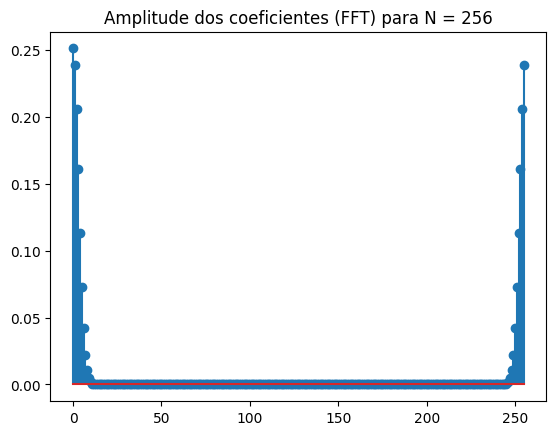

<ipython-input-16-af482da57535>:44: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  plt.stem(np.abs(diff), use_line_collection=True)


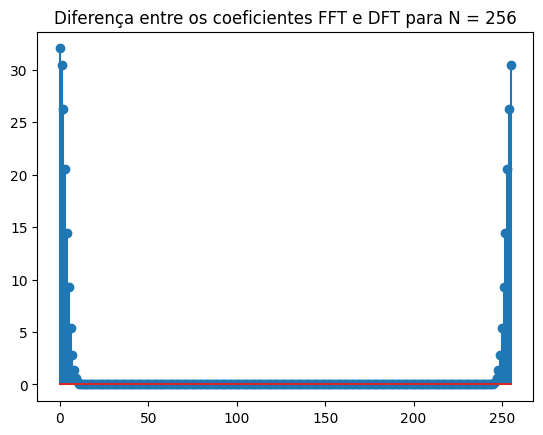

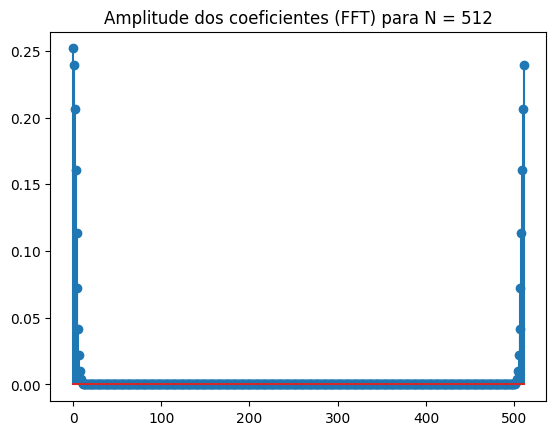

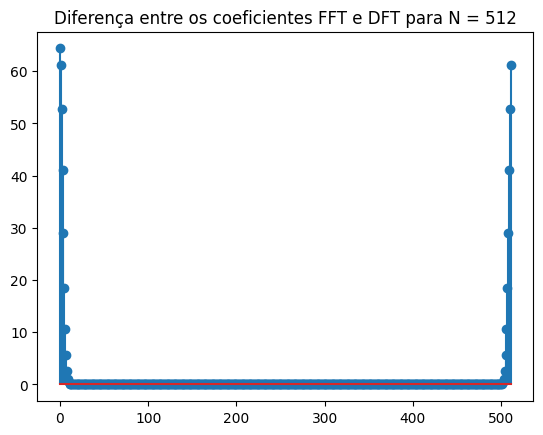

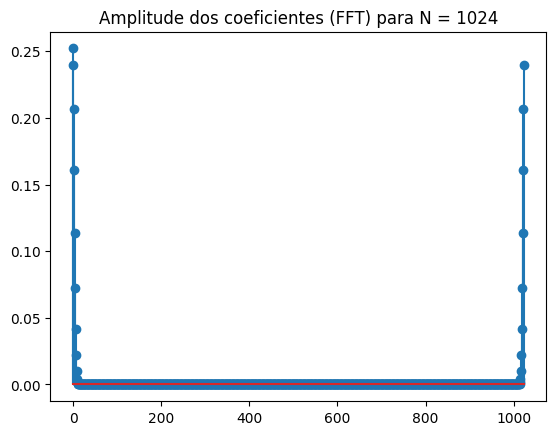

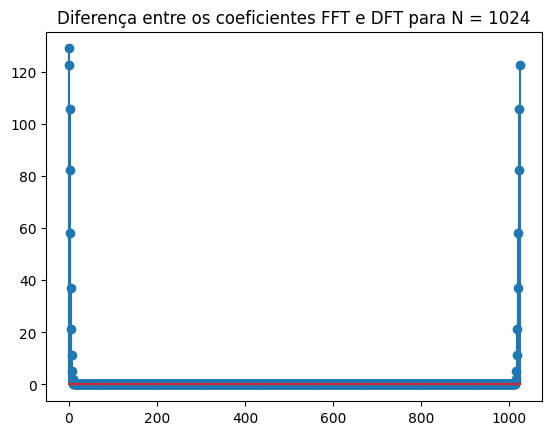

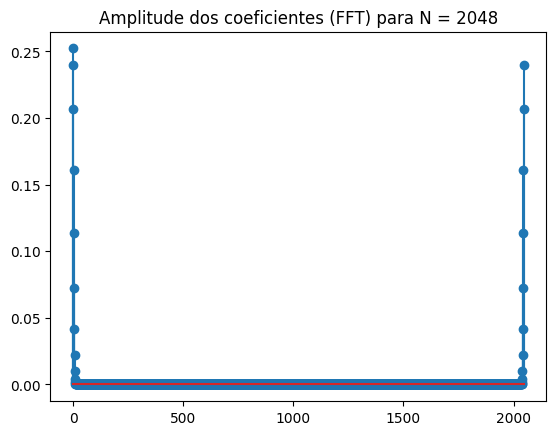

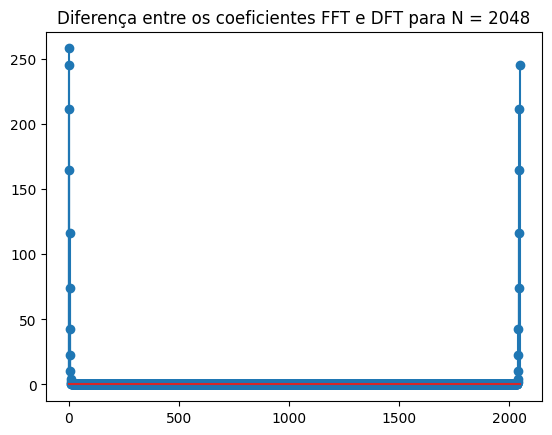

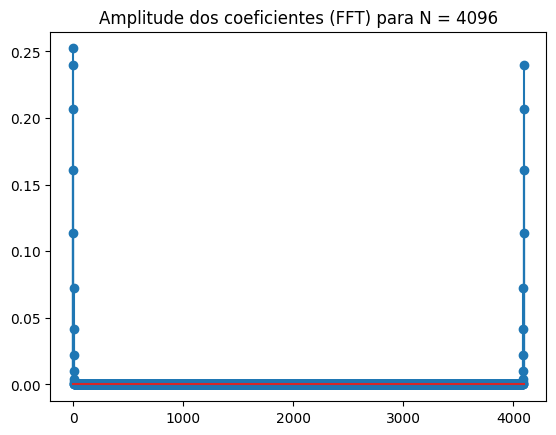

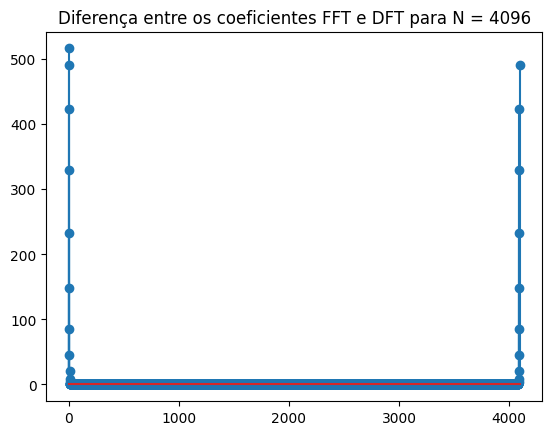

N = 2^8, Tempo de Execução (FFT) = 0.006485700607299805 s
N = 2^9, Tempo de Execução (FFT) = 0.011649608612060547 s
N = 2^10, Tempo de Execução (FFT) = 0.019750118255615234 s
N = 2^11, Tempo de Execução (FFT) = 0.05649518966674805 s
N = 2^12, Tempo de Execução (FFT) = 0.09679532051086426 s


In [ ]:
# Código

import time

# Função para a FFT de Cooley-Tukey
def fft(x):
    N = len(x)
    if N == 1:
        return x
    else:
        pares = fft(x[::2])
        impares = fft(x[1::2])
        exp = np.exp(-2j*np.pi*np.arange(N) / N)
        return np.concatenate([pares + exp[:N//2] * impares, pares + exp[N//2:] * impares])

# Lista para armazenar tempos de execução
execution_times_fft = []

for m in m_values:
    N = 2 ** m
    x = np.linspace(0, 2*np.pi, N)
    F = f(x)

    start_time = time.time()
    c_fft = fft(F)
    end_time = time.time()

    execution_times_fft.append(end_time - start_time)

    # Normalizando os coeficientes
    c_fft /= N

    # Plotando a amplitude dos coeficientes
    A_fft = 2 * np.abs(c_fft)
    plt.figure()
    plt.stem(A_fft, use_line_collection=True)
    plt.title('Amplitude dos coeficientes (FFT) para N = {}'.format(N))
    plt.show()

    # Comparando com a DFT
    c_dft = DFT(F)
    diff = c_fft - c_dft
    plt.figure()
    plt.stem(np.abs(diff), use_line_collection=True)
    plt.title('Diferença entre os coeficientes FFT e DFT para N = {}'.format(N))
    plt.show()

# Imprimindo os tempos de execução
for m, exec_time_fft in zip(m_values, execution_times_fft):
    print("N = 2^{}, Tempo de Execução (FFT) = {} s".format(m, exec_time_fft))


Comentários:



---



A transformada rápida de Fourier (FFT) tem implementações no pacote Numpy e Scipy. A transfomação feita as vezes varia de implementação para implementação, geralmente por um fator que depende de $N$, por isso, é importante conhecer o que está por trás da implementação:

https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html

https://docs.scipy.org/doc/scipy/tutorial/fft.html

Vejamos como funcionam as transformadas desses pacotes, e note que precisamos dividir por $N$ para termos resultados comparáveis a nossa DFT. A diferença aqui é simplesmente pois nos pacotes o fator $1/N$ é colocado na tranformada inversa, e não na direta, por conveniência computacional.

(0.0, 16.0)

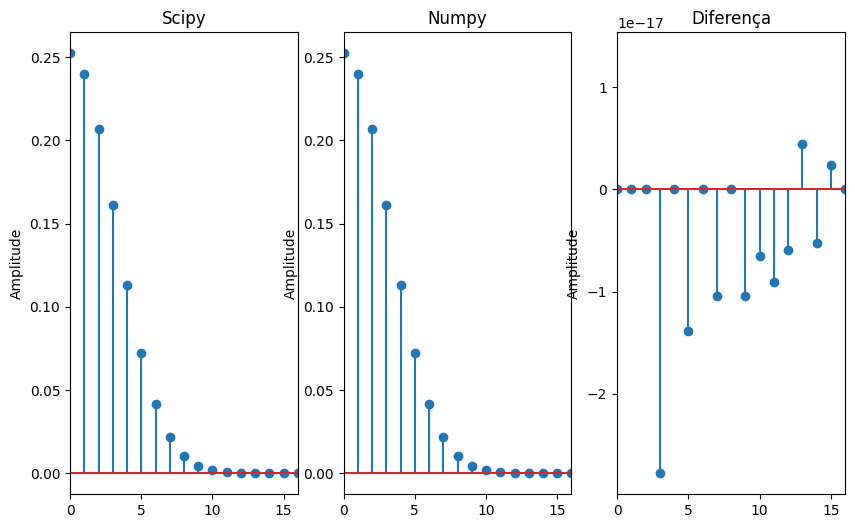

In [ ]:
import scipy.fft as spfft
import numpy.fft as npfft

def f(x):
  return np.exp(-5*(x-np.pi)**2)


N=128
x = np.arange(0, 2*np.pi, 2*np.pi/N)

#FFT scipy - amplitudes
f_sp = 2*np.abs(spfft.fft(f(x))/N)

#FFT numpy - amplitudes
f_np = 2*np.abs(npfft.fft(f(x))/N)


figure, axs = plt.subplots(1, 3, figsize=(10,6))

plt.subplots_adjust(hspace=0.8)

axs[0].stem(f_sp[:N])
axs[0].set_title("Scipy")
axs[0].set_ylabel("Amplitude")
axs[0].set_xlim(0,16)

axs[1].stem(f_np[:N])
axs[1].set_title("Numpy")
axs[1].set_ylabel("Amplitude")
axs[1].set_xlim(0,16)

axs[2].stem(f_sp[:N]-f_np[:N])
axs[2].set_title("Diferença")
axs[2].set_ylabel("Amplitude")
axs[2].set_xlim(0,16)

#### 🧩 Atividade opcional 🧩

Verifique agora o tempo de execução de todos esses métodos que foi exposto. É natural de se esperar que os métodos das bibliotecas fiquem mais rápidos, pois são funções pre-compiladas, mas é importante verificar que elas também tem complexidade computacional de $O(N\log(N))$, como a nossa FFT.





---



## Aplicações

Agora que já estudamos algumas características das transformadas discretas de Fourier, vamos à aplicações práticas.

Neste exercı́cio programa trabalharemos com o conceito de decomposição de sinais, decompondo sons em suas
frequências. Esse processo é conhecido por análise harmônica, e é parte da teoria de aproximações que vimos em sala, quando discutimos o Método dos Mínimos Quadrados.

Qualquer movimento vibratório de ar na entrada do ouvido corresponde a um tom musical que pode ser
sempre, e de maneira única, exibido como uma soma de um número infinito de movimentos vibratórios simples,
correspondendo aos sons parciais desse som. Em uma música, cada frequência apresenta uma amplitude, e a
composição de frequências leva a formação do som. O Teorema de Fourier nos permite decompor um som, que
pode ser representado por uma função, em suas diversas frequências.

O objetivo desta parte da atividade é decompor sons em suas frequências, analisar as frequências dominantes e aplicar filtros, compressões e outras ferramentas interessantes.

### Preliminares

In [ ]:
#Biblioteca para converter texto em som
!pip install gTTS
from gtts import gTTS

#Biblioteca para converter mp3 em wav
!pip install pydub
from pydub import AudioSegment

#Bibliotecas para ouvir sons no próprio Python
from IPython.display import Audio, display

#Biblioteca para ler e escrever arquivos de audio em wav
from scipy.io import wavfile


### Sons e Python

Vamos começar baixando alguns sons e músicas para "brincarmos". Você pode fazer upload para Google Colab de suas própria músicas também.

In [ ]:
!wget https://www.ime.usp.br/~pedrosp/data/sounds/Queen.wav
!wget https://www.ime.usp.br/~pedrosp/data/sounds/StarWars.wav
!wget https://www.ime.usp.br/~pedrosp/data/sounds/ComputerCrash.wav

Se quiser ouvir algum som no próprio notebook, basta usar o IPython

In [ ]:
from IPython.display import Audio, display

audio1_original = 'StarWars.wav'
display(Audio(audio1_original))

audio2_original = 'ComputerCrash.wav'
display(Audio(audio2_original))

audio3_original = 'Queen.wav'
display(Audio(audio3_original))


Agora precisamos transformar esses audios em dados (vetor de números), para podermos tratar com nossa transformadas discretas de Fourier.

*  Os audios são armazenados com uma certa taxa de amostragem (dados/segundo), que fornece uma medida de qualidade do audio (quanto maior a amostragem, mais detalhes do som temos). Por exemplo, em áudios gravados em CDs temos 44.1 kHz de taxa de amostragem, isto é, a cada segundo, gravamos 44100 dados. É comum hoje em dia audios de streaming viram com 48kHz de amostragem. Sons mais simples são armazenados com 24kHz de taxa de amostragem.

* **Importante:** vamos trabalhar com audios em ".wav" com apenas um canal (mono). Neste caso, os dados serão sempre números inteiros. Veja no exemplo a seguir.

In [ ]:
#Ler arquivo de audio
amostragem, sinal = wavfile.read(audio1_original)
# amostragem indica quantos dados por segundo o arquivo possui

#Precisamos ter um número par de dados...
N = sinal.shape[0]
if (N % 2) == 1:
    print("Joguei fora a última amostra para ter um número par...")
    sinal = sinal[:-1] #Vamos jogar fora o último dado se for impar :-(

#Informações do sinal
N = sinal.shape[0]    #Número de dados no vetor
duracao = sinal.shape[0] / amostragem
maxfreq = amostragem/2
print("Amostras (N):", N)
print("Taxa de amostragem:", amostragem, " dados por segundo")
print("Duração audio:", duracao, " seg")
print("Frequência máxima (Nyquist):", N/2, " amostras por ", duracao, "segundos")
print("Frequência máxima (Nyquist) em Hz:", maxfreq, "Hz")
print("Exemplo de 10 elementos do meio do sinal:", sinal[int(N/2)-5:int(N/2)+5])

#Tempos amostrados
t = np.linspace(0., duracao, N)

#Gráfico
plt.plot(t, sinal, linewidth=0.1)
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")

plt.show()



Agora vamos ver como a transformada de Fourier fica para este sinal. Vamos usar Numpy, por conveniência e eficiência, mas você pode (deve!) testar com as outras funções implementadas.

O mais importante neste ponto é entendermos como os coeficientes de Fourier são armazenados na memória, e como se relacionam com as frequências em Hz.

* Os coeficientes de Fourier seguem os mesmo índices que usamos na nossa DFT, ou seja, os números de onda (frequências) variam da seguinte forma:
$$ 0, 1, 2, ..., N/2, N/2+1, N/2+2, ...., N-2, N-1, $$
porém, lembre-se que há uma simetria dos coeficientes, isto é, para funções reais, o espectro é simétrico, pois o coeficiente de número de onda $k$ é o complexo conjugado do de número de onda $N-k$, então as frequências que os números representam são na verdade dadas nas seguinte ordem
$$ 0, 1, 2, ..., N/2-1, N/2, N/2-1, N/2-2, ...., 3,2,1, $$
onde $N/2$ é maior frequência representável por esses $N$ dados (frequência de Nyquist).

In [ ]:
# Espectro completo de Fourier
spec = npfft.fft(sinal)/(N) #Estamos dividindo por N para ficar igual ao nosso DFT

#Gráfico
plt.plot(np.arange(N), np.abs(spec), linewidth=0.1)
plt.xlabel("k")
plt.ylabel("Amplitude")
plt.show()

Note a simetria dos coeficientes em relação ao meio ($N/2$). Se quisermos ver como ficam as amplitudes para cada harmônico, considerando cada número de onda (k) em frequência (Hz), podemos fazer o seguinte:

In [ ]:
#Frequencias possíveis em Hz
f = np.linspace(0., maxfreq, int(N/2)+1) #Numeros de onda de 0 até N/2, ajustados pela freq max

plt.plot(f/1000, 2*np.abs(spec[:int(N/2)+1]), linewidth=0.1)
plt.xlabel("Frequência (kHz)")
plt.ylabel("Amplitude")

plt.show()

Se quisermos recuperar o sinal, basta usarmos a transformada inversa, lembrando de multiplicar o spectro por N e de converter novamente para inteiros para podermos ouvir como um audio!

OBS: Poderíamos simplesmente trabalhar sem dividir/multiplicar por N a transformada e sua inversa, a única ressalva é que as amplitudes dos espectros não dariam iguais aos nosso experimentos iniciais, mas todo o resto funcionaria igualmente.

In [ ]:
#Reconstruindo o sinal (lembre-se de devolver a normalização que fizemos antes!)
sinal_reconst = npfft.ifft(spec*(N)).real

#Vamos salvar como audio novamente (devemos salvar como inteiros para o formato wav!!)
audio1_saida = audio1_original.replace(".wav", "_reconst.wav")
wavfile.write(audio1_saida, amostragem, sinal_reconst.astype(np.int16))
display(Audio(audio1_saida))

Neste exemplo, o som recuperado deve ser idêntico ao original, a menos de pequenas diferenças devido a aritmética de ponto flutuante. Quando convertemos esses sinais para inteiros, isso pode levar a uma diferença de "1" inteiro em algum lugar, por conta de arredondamentos.

In [ ]:
sinal_reconst = npfft.ifft(spec*(N)).real
print("Diferença máxima nos reais:", np.max(np.abs(sinal - sinal_reconst)))
print("Diferença máxima com arredondamento para inteiros:", np.max(np.abs(sinal - sinal_reconst.astype(np.int16))))

### Filtragem de frequências

Vejamos um exemplo onde cortamos toda a energia do espectro de Fourier relativo a uma certa faixa de frequências. Depois podemos reconstruir o som, com a transformada inversa de Fourier, e ouvir o resultado.

OBS: Sabemos que a taxa de amostragem ($a$) é o número de ciclos por segundo do audio, e que o audio tem $N$ amostras no período total do audio (duração), $T$, segundos. Então, a relação entre o número de onda $k$ e sua respectiva frequência ($\omega$), em Hz, pode ser deduzida como

$$ \omega = k/T$$


In [ ]:
#Frequencia de corte em Hz
freq_corte = 1000 # em Hz

#Qual é o número de onda que realiza esse corte?
k_corte=int(freq_corte*duracao)
print("Frequência de corte:", freq_corte, "Hz")
print("Número de onda de corte:", k_corte)

#Precisamos cortar (zerar) frequências maiores que esta, então precisamos cortas números de (k) maiores que k_corte
# mas precisamos prestar atenção na simetria para zerar os complexos conjugados!
# As altas frequências ficam no meio do espectro, pela ordem vista anteriormente.

#Vamos fazer uma cópia para não bagunçar o espectro original
spec_filt = np.copy(spec)

#zeramos primeiro de k_corte até Nyquist (incluso)
#mas também de Nyquist até (N-k_corte), pela simetria.
spec_filt[k_corte:-k_corte] = 0.0

#Gráfico
plt.plot(np.arange(N), np.abs(spec_filt), linewidth=0.1)
plt.xlabel("k")
plt.ylabel("Amplitude")
plt.show()

Vejamos o que obtemos ao fazer a reconstrução do sinal a partir desse espectro filtrado.

In [ ]:
#Reconstruindo o sinal (lembre-se de devolver a normalização que fizemos antes!)
sinal_filt = npfft.ifft(spec_filt*(N)).real

figure, axs = plt.subplots(3, 2, figsize=(10,6))

plt.subplots_adjust(hspace=0.8)

axs[0, 0].plot(t, sinal, linewidth=0.1)
axs[0, 0].set_xlabel("Tempo (s)")
axs[0, 0].set_ylabel("Amplitude")
axs[0, 0].set_title("Sinal original")

axs[0, 1].plot(f/1000, 2*np.abs(spec[:int(N/2)+1]), linewidth=0.1)
axs[0, 1].set_title("Espectro Original")
axs[0, 1].set_xlabel("Frequência (kHz)")
axs[0, 1].set_ylabel("Amplitude")

axs[1, 0].plot(t, sinal_filt, linewidth=0.1)
axs[1, 0].set_xlabel("Tempo (s)")
axs[1, 0].set_ylabel("Amplitude")
axs[1, 0].set_title("Sinal Filtrado")

axs[1, 1].plot(f/1000, 2*np.abs(spec_filt[:int(N/2)+1]), linewidth=0.1)
axs[1, 1].set_title("Espectro filtrado")
axs[1, 1].set_xlabel("Frequência (kHz)")
axs[1, 1].set_ylabel("Amplitude")


axs[2, 0].plot(t, sinal_filt-sinal, linewidth=0.1)
axs[2, 0].set_xlabel("Tempo (s)")
axs[2, 0].set_ylabel("Amplitude")
axs[2, 0].set_title("Diferença sinais")

axs[2, 1].plot(f/1000, np.abs(spec_filt[:int(N/2)+1]-spec[:int(N/2)+1]), linewidth=0.1)
axs[2, 1].set_title("Diferença de Espectro")
axs[2, 1].set_xlabel("Frequência (kHz)")
axs[2, 1].set_ylabel("Amplitude")

plt.show()

In [ ]:
#Vamos salvar como audio novamente (devemos salvar como inteiros para o formato wav!!)
audio1_saida = audio1_original.replace(".wav", "_filtrado.wav")
wavfile.write(audio1_saida, amostragem, sinal_filt.astype(np.int16))
display(Audio(audio1_saida))

Percebe que os sons de alguns instrumentos simplesmente sumiram?!

#### 🧩 Atividade opcional 🧩

Experimente fazer a filtragem com outras frequências de corte.



---



### Compactação/Compressão de áudios

Em geral, os sons podem ser muito bem representado com poucas frequências. Por exemplo, se temos um
som composto por 1 segundo e que tenha 10.000 valores, dependendo de sua complexidade, pode ser que com
menos que 100 frequências já seja possı́vel representar muito bem este som. Métodos de compressão de música
usam esse pressuposto para armazenamento. Ao invés de armazenar os 10.000 valores, armazenam-se os 100
coeficientes de Fourier, e quando for necessário obter os valores, para ouvir a música, aplica-se a transformada
inversa de Fourier.

Nesta atividade, vamos analisar taxas de compressão de áudios. Para a taxa de compressão, dado um limiar $\epsilon$, de um sinal com $N$ elementos, contamos quantos coeficientes (em módulo) tem valores (em módulo) abaixo deste limiar ($n_{\epsilon}$ ) e calculamos a taxa de compressão como
$$T_{\epsilon} = \frac{n_{\epsilon}}{N} 100 \%$$

Para verificarmos se a compressão está sendo adequada, podemos zerar os coeficientes com valores (em módulo) menores que $\epsilon$ e reconstruir o som. Com isso, é possı́vel verificar o que foi perdido do som, ouvindo-o.

Naturalmente ao jogarmos fora muitos coeficientes de Fourier, reduzimos a complexidade do som, mas esperamos fazer isso sem descartar o essencial. Por exemplo, quando um músico toca a nota dó em um piano,
enquanto estiver tocando somente esta nota, estará emitindo um som com apenas uma frequência. Isso significa que ao fazermos a decomposição do som em série de Fourier haverá apenas um coeficiente, o que refere-se a frequência da nota dó.

Dependendo do som, esse tipo de técnica também pode ser usada para filtrar ruı́dos. Além disso, para
comprimir músicas sem perda de qualidade para uma pessoa ouvi-la, é possı́vel também eliminar as frequências
inaudı́veis dos seres humanos. As frequências audíveis variam de 20 Hz e 20 KHz.

#### ❗Exercício 5 ❗


1. Implemente uma função de compressão e uma de descompressão da seguinte forma:

    1.  Compressão: deve receber o sinal e um parâmetro $\epsilon$, realizar a transformada de Fourier e zerar coeficientes com amplitudes menores que $\epsilon$. O parâmetro pode ser relativo considerando um $\%$ da amplitude máxima do espectro do sinal. O espectro de Fourier deve então ser salvo sem os zeros (para economizar espaço na memória). Uma forma de fazer isso é montando 2 vetores: (i) vetor de inteiros com os índices ($k$) dos harmônicos não nulos e um vetor com os valores (complexos) do espectro de Fourier para os respectivos números de ondas relevantes para o sinal. A sua função deve devolver esses 2 vetores.
    2.  Descompressão: deve receber os 2 vetores do sinal comprimido, remontar o espectro completo (preenchendo os zeros), e fazer a transformada inversa de Fourier para reconstruir o sinal. A função deve devolver o sinal reconstruído de forma que possa ser depois ouvido como um audio .wav.

2. Usando as funções implementadas, calcule a taxa de compressão para $\epsilon=1\%, 5\%, 10\%$ da amplitude máxima do espectro de sinal usando o audio2_original ("ComputerCrash.wav"). Avalie a qualidade do som reconstruído em cada caso, ouvindo o som obtido. Comente cada caso.

Dicas:
* Faça gráficos do espectro para auxiliar você na verificação do correto arranjo das frequências e cortes.
* Cuidado com a ordem dos números de onda! Você pode usar a simetria do espectro, ou não, como preferir, mas é claro que usando a simetria já temos um ganho de memória de pelo menos metade de não usarmos!


In [ ]:
# Som de teste
display(Audio(audio2_original))

amostragem, sinal = wavfile.read(audio2_original)
# amostragem indica quantos dados por segundo o arquivo possui

#Precisamos ter um número par de dados...
N = sinal.shape[0]
if (N % 2) == 1:
    print("Joguei fora a última amostra para ter um número par...")
    sinal = sinal[:-1] #Vamos jogar fora o último dado se for impar :-(

#Informações do sinal
N = sinal.shape[0]    #Número de dados no vetor
duracao = sinal.shape[0] / amostragem
maxfreq = amostragem/2
print("Amostras (N):", N)
print("Taxa de amostragem:", amostragem, " dados por segundo")
print("Duração áudio:", duracao, " seg")
print("Frequência máxima (Nyquist) em Hz:", maxfreq, "Hz")




In [ ]:
# Códigos

#Compressão
def compressão(sinal):
    return
import numpy as np
import numpy.fft as fft
from scipy.io import wavfile

def compressao(sinal, epsilon):
    #Transformada de Fourier
    spec = fft.fft(sinal)

    #Encontra a amplitude máxima
    amplitude_max = np.abs(spec).max()

    #Zera os coeficientes menores que a amplitude máxima vezes epsilon
    spec[np.abs(spec) < epsilon * amplitude_max] = 0

    #Retorna um vetor de índices dos coeficientes não nulos e o vetor dos respectivos coeficientes
    return np.nonzero(spec), spec[np.nonzero(spec)]

#Descompressão
def descompressao(indices, valores, N):
    #Cria um vetor de zeros com tamanho N
    spec = np.zeros(N, dtype=complex)

    #Coloca os valores nos respectivos índices
    spec[indices] = valores

    #Faz a transformada inversa de Fourier
    sinal_reconstruido = np.real(fft.ifft(spec))

    return sinal_reconstruido



Comentários:



---






### Mensagens secretas

A última aplicação que vamos discutir é o problema de Estenografia (do grego "escrita escondida"). Vamos tentar colocar uma mensagem secreta em um som usando transformadas de Fourier.

Primeiro vamos definir um segrego:

In [ ]:
# Return a single random word
text = "meu segredo"
audiofile = "meusegredo"

#Vamos passar esse texto para um audio, usando o Google Text to Speach
som = gTTS(text=text, lang='pt', slow=False) #gera som
som.save(audiofile+".mp3") #salva em mp3
sound = AudioSegment.from_mp3(audiofile+".mp3") #le som mp3
sound = sound.split_to_mono() #vamos garantir que tenhamos um sinal mono (1 canal), para facilitar
sound[0].export(audiofile+".wav", format="wav") #converte para wav e usa apenas um canal
audiofile = audiofile+".wav" #vamos guardar esse nome de arquivo

# convert wav to mp3
display(Audio(audiofile))

Agora vamos definir uma musica de fundo, para esconder nosso segredo.

In [ ]:
audiofundo = audio3_original
display(Audio(audiofundo))

In [ ]:
#---------------------------------------
#Ler arquivo de áudio com segredo
#------------------------------------

amostragem, sinal = wavfile.read(audiofile)
N = sinal.shape[0]
if (N % 2) == 1:
    sinal = sinal[:-1] #Vamos jogar fora o último int se for impar
N = sinal.shape[0]
duracao = sinal.shape[0] / amostragem
maxfreq = amostragem/2
print("Sinal a ser codificado")
print("Amostras:", N)
print("Taxa de amostragem:", amostragem, " dados por segundo")
print("Duração áudio:", duracao, " seg")
print("Frequência máxima:", maxfreq, "Hz")
print("")

# Espectro completo de Fourier
spec = npfft.fft(sinal)/N

#-----------------------------------
#Ler arquivo de áudio de Fundo
#---------------------------------

amostragem_f, sinal_f = wavfile.read(audiofundo)
N_f = sinal_f.shape[0]
if (N_f % 2) == 1:
    sinal_f = sinal_f[:-1] #Vamos jogar fora o último int se for impar
N_f = sinal_f.shape[0]
duracao_f = sinal_f.shape[0] / amostragem_f
maxfreq_f = amostragem_f/2
print("Sinal de fundo:")
print("Amostras:", N_f)
print("Taxa de amostragem:", amostragem_f, " dados por segundo")
print("Duração áudio:", duracao_f, " seg")
print("Frequência máxima:", maxfreq_f, "Hz")

# Espectro de Fourier do fundo
spec_f = npfft.fft(sinal_f)/(N_f)


Vamos ver gráficos desses sinais e seus espectros

In [ ]:
figure, axs = plt.subplots(2, 2, figsize=(10,8))

#plt.subplots_adjust(hspace=0.8)

#Sinal a ser codificado
axs[0, 0].plot(np.linspace(0., duracao, N), sinal, linewidth=0.1)
axs[0, 0].set_xlabel("Tempo (s)")
axs[0, 0].set_ylabel("Amplitude")
axs[0, 0].set_title("Sinal secreto")

axs[1, 0].plot(np.arange(N), 2*np.abs(spec), linewidth=0.1)
axs[1, 0].set_xlabel("número de onda (k)")
axs[1, 0].set_ylabel("Amplitude")

# Sinal de fundo
axs[0, 1].set_title("Sinal de fundo")
axs[0, 1].plot(np.linspace(0., duracao_f, N_f), sinal_f, linewidth=0.1)
axs[0, 1].set_xlabel("Tempo (s)")

axs[1, 1].plot(np.arange(N_f), 2*np.abs(spec_f), linewidth=0.1)
axs[1, 1].set_xlabel("Número de onda (k)")

plt.show()

Vamos esconder a mensagem adicionando como altas frequências no som de fundo! Vamos colocar um fator que reduz a amplitude do som secreto, para despistar, é claro...

In [ ]:
# fator para reduzir amplitude da parte escondida
fator=1.0/np.max(np.abs(spec_f))

#Espectro com os dois sinais, sendo o sinal secreto no "meio"
spec_com_segredo = np.copy(spec_f)
spec_com_segredo[int(N_f/2-N/2):int(N_f/2+N/2)] = fator*spec

# Se não mudamos o tamanho do espectro, mantemos a amostragem do audio de fundo
amostragem_com_segredo = amostragem_f

plt.plot(np.abs(spec_com_segredo), linewidth=0.1)
plt.show()

Vamos agora ver se o nosso audio misturável ficou audível e mascarou a mesagem secreta.

In [ ]:
#Reconstruindo o sinal (lembre-se de devolver a normalização que fizemos antes!)
sinal_com_segredo = npfft.ifft(spec_com_segredo*(spec_com_segredo.size)).real

plt.plot(sinal_com_segredo, linewidth=0.1)

#Vamos salvar como audio novamente (devemos salvar como inteiros para o formato wav!!)
audio_saida = audiofundo.replace(".wav","_com_msg_screta.wav")
wavfile.write(audio_saida, amostragem_com_segredo, sinal_com_segredo.astype(np.int16))
display(Audio(audio_saida))

Consegue ouvir a mensagem secreta? Conseguiria decifrar a mensagem se recebesse apenas esse audio?

A chave para decodificar a mensagem é simplesmente:
* O número de amostras na mensagem secreta ($N$)

Para reconstruírmos o som, também precisamos da taxa de amostragem do som secreto (combinado de antemão com o recebedor do código).
* A taxa de amostragem da mensagem secreta (amostragem)

In [ ]:
#Decodificando

chave1 = N #amostras da mensagem
chave2 = amostragem #tx de amostragem

#Ler arquivo de audio: audio com mensagem
amostragem_m, sinal_m = wavfile.read(audio_saida)
N_m = sinal_m.shape[0]
duracao_m = sinal_m.shape[0] / amostragem_m
maxfreq_m = amostragem_m/2
print("Sinal com código")
print("Amostras:", N_m)
print("Taxa de amostragem:", amostragem_m, " dados por segundo")
print("Duração audio:", duracao_m, " seg")
print("Frequencia máxima:", maxfreq_m, "Hz")
print("")

# Espectro completo de Fourier
spec_m = npfft.fft(sinal_m)/(N_m)

#Nosso fator de redução (inverso)
fator_inv = np.max(np.abs(spec_m))


#extraindo o espectro do segredo!
spec_segredo = fator_inv*spec_m[int(N_m/2)-int(chave1/2):int(N_m/2)+int(chave1/2)]


In [ ]:
#Reconstruindo o sinal (lembre-se de devolver a normalização que fizemos antes!)
sinal_decodif = npfft.ifft(spec_segredo*(spec_segredo.size)).real

audio_decod = audio_saida.replace(".wav", "_msg_decodificada.wav")
wavfile.write(audio_decod, chave2, sinal_decodif.astype(np.int16))
display(Audio(audio_decod))

#### ❗Exercício 6 ❗

Considere o arquivo de som "desafio-pos.wav", que pode ser baixado com o comando logo abaixo. Há uma mensagem codificada neste áudio. A chave é 104832 e a taxa de amostragem do segredo é de 24000 Hz. Decifre a mensagem!

Além de decifrar a mensagem, comente os aspectos que achou interessante da atividade como todo, curiosidades, experimentos extras, problemas e dificuldades encontradas.

In [ ]:
!wget https://www.ime.usp.br/~pedrosp/data/sounds/desafio-poli.wav

--2023-06-15 06:03:34--  https://www.ime.usp.br/~pedrosp/data/sounds/desafio-poli.wav
Resolving www.ime.usp.br (www.ime.usp.br)... 200.144.244.77
Connecting to www.ime.usp.br (www.ime.usp.br)|200.144.244.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9068588 (8.6M) [audio/x-wav]
Saving to: ‘desafio-poli.wav’

desafio-poli.wav    100%[===================>]   8.65M  3.69MB/s    in 2.3s    

2023-06-15 06:03:38 (3.69 MB/s) - ‘desafio-poli.wav’ saved [9068588/9068588]



In [ ]:
display(Audio("desafio-poli.wav"))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#Códigos

import numpy as np
from scipy.io import wavfile
from numpy import fft as npfft
from IPython.display import Audio

# Chave e taxa de amostragem do segredo
chave1 = 104832
chave2 = 24000

# Leitura do arquivo de áudio: áudio com mensagem
amostragem_m, sinal_m = wavfile.read('desafio-poli.wav')
N_m = sinal_m.shape[0]
duracao_m = sinal_m.shape[0] / amostragem_m
maxfreq_m = amostragem_m/2

# Espectro completo de Fourier
spec_m = npfft.fft(sinal_m)/(N_m)

# Fator de redução (inverso)
fator_inv = np.max(np.abs(spec_m))

# Extração do espectro do segredo!
spec_segredo = fator_inv*spec_m[int(N_m/2)-int(chave1/2):int(N_m/2)+int(chave1/2)]

# Reconstrução do sinal (devolvendo a normalização que foi feita antes)
sinal_decodif = npfft.ifft(spec_segredo*(spec_segredo.size)).real

# Salva o áudio decodificado
audio_decod = 'desafio-poli_decodificado.wav'
wavfile.write(audio_decod, chave2, sinal_decodif.astype(np.int16))

# Reproduz o áudio decodificado
Audio(audio_decod)

Comentários:



---




🧩 Observação 🧩

Esse algoritmo de mensagem escondida é bem simples e tem alguns defeitos. Consegue identificar alguns?

Porém, é possível usar issa ideia de esconder informações no espectro de Fourier para construir métodos mais robustos.

In [ ]:
Robustez: Este método não é muito robusto para perturbações. Qualquer alteração no áudio, como compressão de áudio ou ruído de fundo, pode distorcer ou destruir completamente a mensagem secreta.

Detecção: Embora a mensagem esteja escondida, ela ainda pode ser detectada por uma análise cuidadosa do espectro de Fourier. Uma grande amplitude em frequências altas, que normalmente não estão presentes em arquivos de áudio comuns, pode revelar a presença de uma mensagem escondida.

Tamanho da mensagem: A mensagem que pode ser escondida é limitada pelo tamanho do áudio de fundo. Se a mensagem for muito longa, não será possível escondê-la sem distorcer significativamente o áudio original.

Qualidade da mensagem: Como a mensagem está sendo escondida nas frequências mais altas do áudio, a qualidade do áudio secreto pode ser bastante baixa, especialmente se o áudio original já contiver informações de alta frequência.

Complexidade: Exige conhecimento e habilidades técnicas, além de software específico ou codificação personalizada para implementar e usar.

SyntaxError: ignored